In [1]:
from torchvision.datasets import MNIST, FashionMNIST, CIFAR10
import torchvision
import numpy as np
import random

import torch
import torch.nn.functional as F
import cl_gym as cl

import sys
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

init_path = os.path.abspath('.')
new_path = init_path
while True:
    if new_path[-3:] == "FSW":
        sys.path.append(new_path)
        break
    new_path = os.path.abspath('..')
    os.chdir(new_path)

seed = 0

np.random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)
torch.manual_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False
torch.set_num_threads(8)

def make_params() -> dict:
    import os
    from pathlib import Path
    import uuid

    params = {
            'debug': "True",

            # dataset
            'dataset': "MNIST",
            'fairness_agg': 'mean',
            'model': 'MLP',

            # benchmark
            'seed': seed,
            'num_tasks': 5,
            'epochs_per_task': 5,
            'per_task_examples': np.inf,
            # 'per_task_examples': 10000,
            'per_task_memory_examples': 128,
            'batch_size_train': 64,
            'batch_size_memory': 64,
            'batch_size_validation': 256,
            'tau': 10.0,

            # algorithm
            'optimizer': 'sgd',
            'learning_rate': 0.001,
            'momentum': 0.9,
            'learning_rate_decay': 1.0,
            'criterion': torch.nn.CrossEntropyLoss(),
            # 'criterion': torch.nn.BCEWithLogitsLoss(),

            'device': torch.device('cuda:6' if torch.cuda.is_available() else 'cpu'),
             
            # sample selection
            'alpha': 0.0005,
            'metric' : "EER",
            'lambda': 1.0,
            'lambda_old': 0.0,

            # # postprocessing
            # "post_processing": "eps_fairness",
            # "pp_eps": 0.0,
              }
    

#     trial_id = str(uuid.uuid4())
    trial_id = f"demo/dataset={params['dataset']}/seed={params['seed']}_epoch={params['epochs_per_task']}_lr={params['learning_rate']}_tau={params['tau']}_alpha={params['alpha']}"
    if params['lambda'] != 0:
        trial_id+=f"_lmbd_{params['lambda']}_lmbdold_{params['lambda_old']}"
    params['trial_id'] = trial_id
    params['output_dir'] = os.path.join("./outputs/{}".format(trial_id))
    print(f"output_dir={params['output_dir']}")
    Path(params['output_dir']).mkdir(parents=True, exist_ok=True)


    return params

params = make_params()

output_dir=./outputs/demo/dataset=MNIST/seed=0_epoch=5_lr=0.001_tau=10.0_alpha=0.0005_lmbd_1.0_lmbdold_0.0


In [2]:
from datasets import MNIST
from datasets import FashionMNIST

if params['dataset'] == 'MNIST':
    benchmark = MNIST(num_tasks=params['num_tasks'],
                    per_task_memory_examples=params['per_task_memory_examples'],
                    per_task_examples = params['per_task_examples'],
                    random_class_idx = False)
    input_dim = (28, 28)
elif params['dataset'] == 'FashionMNIST':
    benchmark = FashionMNIST(num_tasks=params['num_tasks'],
                            per_task_memory_examples=params['per_task_memory_examples'],
                            per_task_examples = params['per_task_examples'],
                            random_class_idx = params['random_class_idx'])
    input_dim = (28, 28)
else:
    raise NotImplementedError
class_idx = benchmark.class_idx
num_classes = len(class_idx)



[0 1 2 3 4 5 6 7 8 9]


In [3]:
from algorithms.imbalance import Heuristic2
from metrics import MetricCollector2
from backbones import MLP2Layers2
from algorithms.clad import CLAD

backbone = MLP2Layers2(
    input_dim=input_dim, 
    hidden_dim_1=256, 
    hidden_dim_2=256, 
    output_dim=num_classes,
    class_idx=class_idx,
    config=params
    ).to(params['device'])

algorithm = Heuristic2(backbone, benchmark, params, requires_memory=True)

metric_manager_callback = MetricCollector2(num_tasks=params['num_tasks'],
                                                        eval_interval='epoch',
                                                        epochs_per_task=params['epochs_per_task'])

In [4]:
from trainers.imbalance_trainer import ImbalanceContinualTrainer1 as ContinualTrainer
trainer = ContinualTrainer(algorithm, params, callbacks=[metric_manager_callback])


In [5]:
trainer.run()
print("final avg-acc", metric_manager_callback.meters['accuracy'].compute_final())
print("final avg-forget", metric_manager_callback.meters['forgetting'].compute_final())

---------------------------- Task 1 -----------------------
[1] Eval metrics for task 1 >> {'accuracy': 0.9980288591207408, 'loss': 5.089056306027633e-05, 'std': 0.0010900836105367517, 'EER': -1}
[2] Eval metrics for task 1 >> {'accuracy': 0.9980288591207408, 'loss': 2.8602778691419754e-05, 'std': 0.0010900836105367517, 'EER': -1}
[3] Eval metrics for task 1 >> {'accuracy': 0.9989795918367347, 'loss': 2.2043606561408257e-05, 'std': 0.0010204081632653184, 'EER': -1}
[4] Eval metrics for task 1 >> {'accuracy': 0.9989795918367347, 'loss': 1.8415540835465665e-05, 'std': 0.0010204081632653184, 'EER': -1}
[5] Eval metrics for task 1 >> {'accuracy': 0.9989795918367347, 'loss': 1.5980565378851923e-05, 'std': 0.0010204081632653184, 'EER': -1}
training_task_end
---------------------------- Task 2 -----------------------
loss_group=tensor([[4.5541e-03, 1.5774e-03, 9.2363e+00, 8.9315e+00]])
Elapsed time(grad):2.889
### Cplex absolute_and_nonabsolute_minsum LP solver ###
Elapsed time(optim):5.578
F

In [31]:
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams['pdf.fonttype'] = 42    
plt.rc('font', size=25)
plt.rc('axes', labelsize=25)
plt.rc('xtick', labelsize=25)
plt.rc('ytick', labelsize=25)
plt.rc('legend', fontsize=25)
plt.rc('figure', titlesize=25)

def draw_plot_loss(eo, ce_eo, title, eo_range=None, ce_eo_range=None):
    num_epochs = len(eo)
    fig = plt.figure(figsize=(15, 6))
    if title is not None or len(title)>0:
        fig.suptitle(title)
    ax1 = fig.add_subplot()
    ax1.grid(False)

    ax1.set_xticks(np.arange(0, num_epochs+1, params['epochs_per_task']), [])
    ax1.set_xlim(0, num_epochs)
    ax1.set_ylim(0, 0.15)

    lns1 = ax1.plot(np.arange(1, num_epochs+1), eo, color = "blue", label="EER Disparity")
    ax1.set_ylabel("EER Disparity")

    ax2 = ax1.twinx()
    ax2.grid(False)
    lns2 = ax2.plot(np.arange(1, num_epochs+1), ce_eo, color = "orange", label="Cost function for EER")
    ax2.set_ylabel("Cost function for EER")
    ax2.set_ylim(0, 0.65)

    # Change the color of the axis to black
    ax1.tick_params(colors='black')
    ax2.tick_params(colors='black')
    ax1.spines['bottom'].set_color('black')
    ax1.spines['top'].set_color('black') 
    ax1.spines['right'].set_color('black')
    ax1.spines['left'].set_color('black')

    ax2.spines['bottom'].set_color('black')
    ax2.spines['top'].set_color('black') 
    ax2.spines['right'].set_color('black')
    ax2.spines['left'].set_color('black')
    
    for i in range(1, params['num_tasks']+1):
        plt.axvline(x=params['epochs_per_task']*i, color = "black", linewidth=1.5, linestyle="dashed")
        plt.text(params['epochs_per_task']*(i-0.5), -0.08, f'Task {i}', ha='center', va='bottom', fontsize=30)


    # ax1.set_xlabel('epochs')
    lns = lns1 + lns2
    labs = [l.get_label() for l in lns]

    # ax1.legend(lns, labs, loc='upper right',)
    ax1.legend(lns, labs, bbox_to_anchor=(0., 1.05, 1., .1), loc='center',
            ncol=10, borderaxespad=0.)

    plt.savefig(f"output.pdf", bbox_inches="tight")
    plt.show()



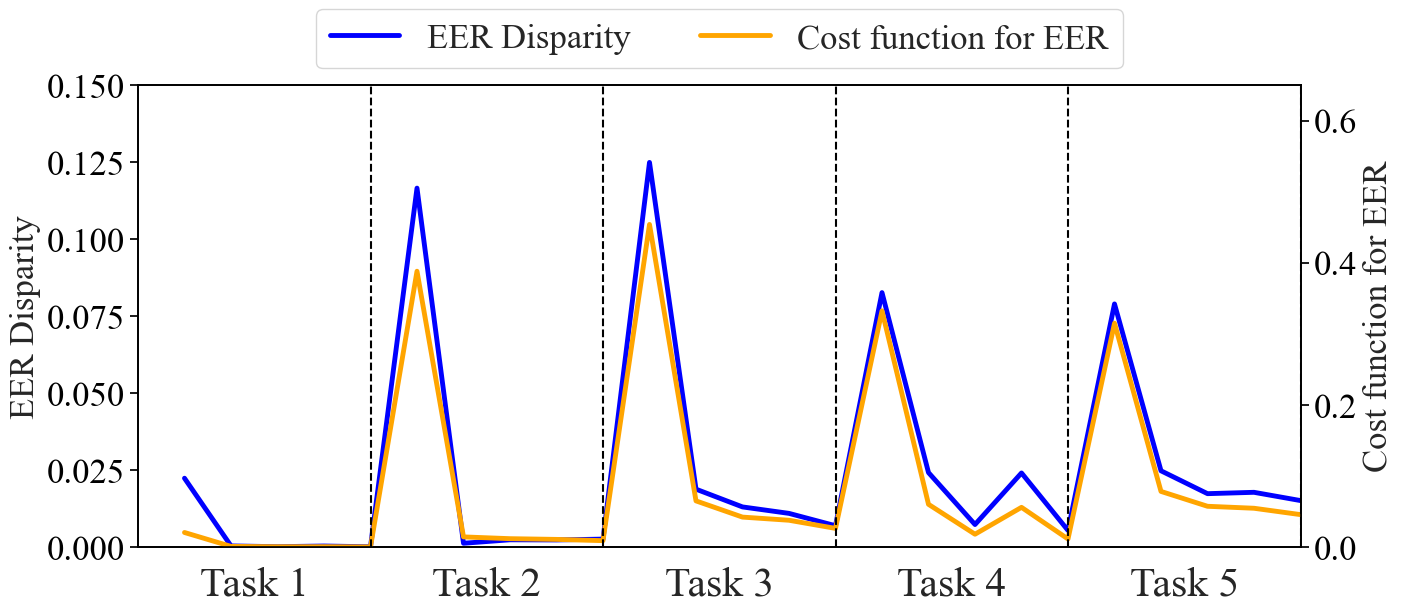

In [32]:
num_epochs = params['epochs_per_task']
num_tasks = params['num_tasks']

title = f""
draw_plot_loss([np.mean(x) for x in algorithm.disp], [np.mean(x) for x in algorithm.CELoss_disp], title, eo_range=None, ce_eo_range=None)